In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. In Colab go to Runtime > Change runtime type > GPU")


CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
REPO_DIR = "/content/drive/MyDrive/AWRaCLe-main"
DATASET_ZIP = "/content/drive/MyDrive/awracle_data.zip"
DATASET_DIR = f"{REPO_DIR}/awracle_data"


In [ ]:
import os

print("Repo exists:", os.path.exists(REPO_DIR), REPO_DIR)
print("Zip exists:", os.path.exists(DATASET_ZIP), DATASET_ZIP)

if not os.path.exists(REPO_DIR):
    raise FileNotFoundError(f"Repo folder not found: {REPO_DIR}")

if not os.path.exists(DATASET_ZIP):
    raise FileNotFoundError(f"Dataset zip not found: {DATASET_ZIP}")


Repo exists: True /content/drive/MyDrive/AWRaCLe-main
Zip exists: True /content/drive/MyDrive/awracle_data.zip


In [ ]:
%cd /content/drive/MyDrive/AWRaCLe-main
!pwd
!ls


/content/drive/MyDrive/AWRaCLe-main
/content/drive/MyDrive/AWRaCLe-main
assets	   LICENSE  options.py	requirements.txt  test.sh  train.py  utils
custom.md  net	    README.md	test.py		  tools    train.sh


In [ ]:
import os

if os.path.exists(DATASET_DIR):
    print("Dataset folder already exists:", DATASET_DIR)
else:
    !unzip -q "{DATASET_ZIP}" -d "{REPO_DIR}"
    print("Dataset extracted to:", DATASET_DIR)


Dataset extracted to: /content/drive/MyDrive/AWRaCLe-main/awracle_data


In [ ]:
!ls "/content/drive/MyDrive/AWRaCLe-main/awracle_data"
!ls "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train"
!ls "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain" | head
!ls "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze" | head
!ls "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow" | head


data_awracle
Dehaze	Derain	Desnow
derain_train_high.json
derain_train_low.json
derain_val_high.json
derain_val_low.json
input
target
clear
dehaze_reside_train_high.json
dehaze_reside_train_low.json
dehaze_reside_val_high.json
dehaze_reside_val_low.json
hazy
data2
desnow_snow100_train_high.json
desnow_snow100_train_low.json
desnow_snow100_val_high.json
desnow_snow100_val_low.json
gt


In [ ]:
DERAIN_DIR = "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain/"
DEHAZE_DIR = "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze/"
DESNOW_DIR = "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow/"

for p in [DERAIN_DIR, DEHAZE_DIR, DESNOW_DIR]:
    print(p, os.path.exists(p))


/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain/ True
/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze/ True
/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow/ True


In [ ]:
!pip install torch torchvision torchaudio pytorch-lightning git+https://github.com/openai/CLIP.git einops opencv-python numpy scipy matplotlib pillow scikit-image scikit-video tqdm natsort lpips torch-fidelity torchmetrics


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-z41rbk3p
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-z41rbk3p
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 120.0 MB/s eta 0:00:00


In [ ]:
!python train.py \
  --de_type derain dehaze desnow \
  --batch_size 22 \
  --num_gpus 1 \
  --num_workers 4 \
  --epochs 50 \
  --derain_dir "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain/" \
  --dehaze_dir "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze/" \
  --desnow_dir "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow/"


Streaming output truncated to the last 5000 lines.
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 1.82it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:07 • 0:00:00 

In [ ]:
# for snow
!python test.py \
  --mode 2 \
  --cuda 0 \
  --ckpt_name "/content/drive/MyDrive/AWRaCLe-main/train_ckpt/epoch=49-step=6100.ckpt" \
  --test_dir "/content/drive/MyDrive/AWRaCLe-main/test_data_snow" \
  --output_path "/content/drive/MyDrive/AWRaCLe-main/test_snow_results/" \
  --degrad_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow/data2/2007_000032.jpg" \
  --clean_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow/gt/2007_000032.jpg"


Setting up inference-only folder dataset
Total Inference Ids : 10
CKPT name : /content/drive/MyDrive/AWRaCLe-main/train_ckpt/epoch=49-step=6100.ckpt
Loaded!
Start testing...
100% 10/10 [00:09<00:00,  1.09it/s]
Inference finished. Restored images saved to /content/drive/MyDrive/AWRaCLe-main/test_snow_results/


In [ ]:
# for rain
!python test.py \
  --mode 2 \
  --cuda 0 \
  --ckpt_name "/content/drive/MyDrive/AWRaCLe-main/train_ckpt/epoch=49-step=6100.ckpt" \
  --test_dir "/content/drive/MyDrive/AWRaCLe-main/test_data_rain" \
  --output_path "/content/drive/MyDrive/AWRaCLe-main/test_rain_results/" \
  --degrad_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain/input/2007_000032.jpg" \
  --clean_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain/target/2007_000032.jpg"


Setting up inference-only folder dataset
Total Inference Ids : 6
CKPT name : /content/drive/MyDrive/AWRaCLe-main/train_ckpt/epoch=49-step=6100.ckpt
Loaded!
Start testing...
100% 6/6 [00:01<00:00,  5.07it/s]
Inference finished. Restored images saved to /content/drive/MyDrive/AWRaCLe-main/test_rain_results/


In [ ]:
# for haze
!python test.py \
  --mode 2 \
  --cuda 0 \
  --ckpt_name "/content/drive/MyDrive/AWRaCLe-main/train_ckpt/epoch=49-step=6100.ckpt" \
  --test_dir "/content/drive/MyDrive/AWRaCLe-main/test_data_haze" \
  --output_path "/content/drive/MyDrive/AWRaCLe-main/test_haze_results/" \
  --degrad_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze/hazy/2007_000032.jpg" \
  --clean_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze/clear/2007_000032.jpg"


Setting up inference-only folder dataset
Total Inference Ids : 10
CKPT name : /content/drive/MyDrive/AWRaCLe-main/train_ckpt/epoch=49-step=6100.ckpt
Loaded!
Start testing...
100% 10/10 [00:07<00:00,  1.32it/s]
Inference finished. Restored images saved to /content/drive/MyDrive/AWRaCLe-main/test_haze_results/


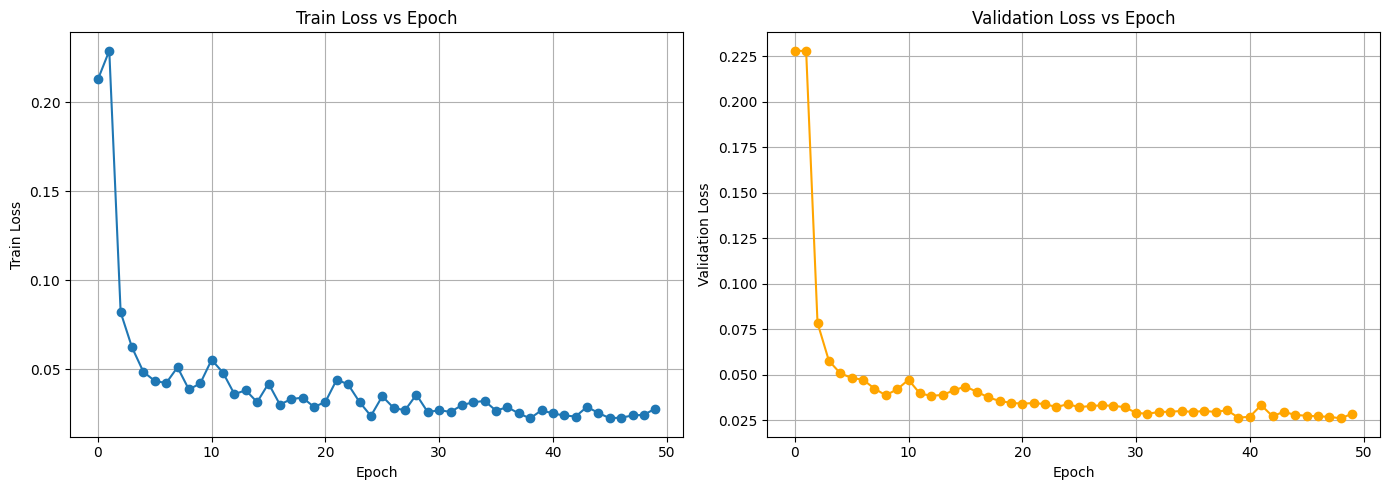

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

metrics_file = "/content/drive/MyDrive/AWRaCLe-main/train_metrics.txt"

rows = []
with open(metrics_file, "r", encoding="utf-8") as f:
    next(f)  # skip header
    for line in f:
        line = line.strip()
        if not line:
            continue
        epoch, stage, metrics_str = line.split("\t", 2)
        metrics = ast.literal_eval(metrics_str)
        rows.append({
            "epoch": int(epoch),
            "stage": stage,
            "train_loss": metrics.get("train_loss"),
            "valid_loss": metrics.get("valid_loss"),
        })

df = pd.DataFrame(rows)

# Keep one value per epoch
train_df = (
    df.dropna(subset=["train_loss"])
      .groupby("epoch", as_index=False)["train_loss"]
      .last()
)

val_df = (
    df.dropna(subset=["valid_loss"])
      .groupby("epoch", as_index=False)["valid_loss"]
      .last()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_df["epoch"], train_df["train_loss"], marker="o")
axes[0].set_title("Train Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train Loss")
axes[0].grid(True)

axes[1].plot(val_df["epoch"], val_df["valid_loss"], marker="o", color="orange")
axes[1].set_title("Validation Loss vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()


WHEN DWT BLOCK ADDED INSIDE DCE BLOCK

In [ ]:
!python train.py \
  --de_type derain dehaze desnow \
  --batch_size 22 \
  --num_gpus 1 \
  --num_workers 4 \
  --epochs 50 \
  --ckpt_dir "train_ckpt_dwt" \
  --log_file "train_metrics_dwt.txt" \
  --derain_dir "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain/" \
  --dehaze_dir "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze/" \
  --desnow_dir "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow/"


Streaming output truncated to the last 5000 lines.
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 1.79it/s  
Epoch 33/49 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122/122 0:01:08 • 0:00:00 

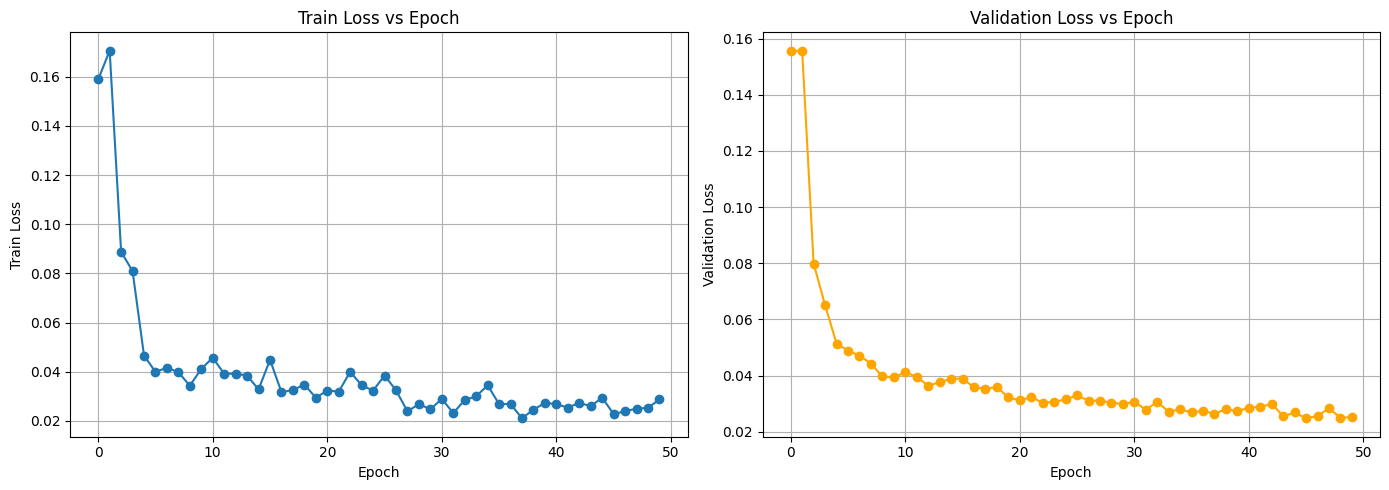

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

metrics_file = "/content/drive/MyDrive/AWRaCLe-main/train_metrics_dwt.txt"

rows = []
with open(metrics_file, "r", encoding="utf-8") as f:
    next(f)  # skip header
    for line in f:
        line = line.strip()
        if not line:
            continue
        epoch, stage, metrics_str = line.split("\t", 2)
        metrics = ast.literal_eval(metrics_str)
        rows.append({
            "epoch": int(epoch),
            "stage": stage,
            "train_loss": metrics.get("train_loss"),
            "valid_loss": metrics.get("valid_loss"),
        })

df = pd.DataFrame(rows)

# Keep one value per epoch
train_df = (
    df.dropna(subset=["train_loss"])
      .groupby("epoch", as_index=False)["train_loss"]
      .last()
)

val_df = (
    df.dropna(subset=["valid_loss"])
      .groupby("epoch", as_index=False)["valid_loss"]
      .last()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_df["epoch"], train_df["train_loss"], marker="o")
axes[0].set_title("Train Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train Loss")
axes[0].grid(True)

axes[1].plot(val_df["epoch"], val_df["valid_loss"], marker="o", color="orange")
axes[1].set_title("Validation Loss vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# for snow
!python test.py \
  --mode 2 \
  --cuda 0 \
  --ckpt_name "/content/drive/MyDrive/AWRaCLe-main/train_ckpt_dwt/epoch=49-step=6100.ckpt" \
  --test_dir "/content/drive/MyDrive/AWRaCLe-main/test_data_snow" \
  --output_path "/content/drive/MyDrive/AWRaCLe-main/test_snow_dwt_results/" \
  --degrad_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow/data2/2007_000032.jpg" \
  --clean_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Desnow/gt/2007_000032.jpg"


Setting up inference-only folder dataset
Total Inference Ids : 10
CKPT name : /content/drive/MyDrive/AWRaCLe-main/train_ckpt_dwt/epoch=49-step=6100.ckpt
Loaded!
Start testing...
100% 10/10 [00:08<00:00,  1.24it/s]
Inference finished. Restored images saved to /content/drive/MyDrive/AWRaCLe-main/test_snow_dwt_results/


In [ ]:
# for rain
!python test.py \
  --mode 2 \
  --cuda 0 \
  --ckpt_name "/content/drive/MyDrive/AWRaCLe-main/train_ckpt_dwt/epoch=49-step=6100.ckpt" \
  --test_dir "/content/drive/MyDrive/AWRaCLe-main/test_data_rain" \
  --output_path "/content/drive/MyDrive/AWRaCLe-main/test_rain_dwt_results/" \
  --degrad_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain/input/2007_000032.jpg" \
  --clean_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Derain/target/2007_000032.jpg"


Setting up inference-only folder dataset
Total Inference Ids : 6
CKPT name : /content/drive/MyDrive/AWRaCLe-main/train_ckpt_dwt/epoch=49-step=6100.ckpt
Loaded!
Start testing...
100% 6/6 [00:05<00:00,  1.15it/s]
Inference finished. Restored images saved to /content/drive/MyDrive/AWRaCLe-main/test_rain_dwt_results/


In [ ]:
# for haze
!python test.py \
  --mode 2 \
  --cuda 0 \
  --ckpt_name "/content/drive/MyDrive/AWRaCLe-main/train_ckpt_dwt/epoch=49-step=6100.ckpt" \
  --test_dir "/content/drive/MyDrive/AWRaCLe-main/test_data_haze" \
  --output_path "/content/drive/MyDrive/AWRaCLe-main/test_haze_dwt_results/" \
  --degrad_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze/hazy/2007_000032.jpg" \
  --clean_context "/content/drive/MyDrive/AWRaCLe-main/awracle_data/data_awracle/Train/Dehaze/clear/2007_000032.jpg"


Setting up inference-only folder dataset
Total Inference Ids : 10
CKPT name : /content/drive/MyDrive/AWRaCLe-main/train_ckpt_dwt/epoch=49-step=6100.ckpt
Loaded!
Start testing...
100% 10/10 [00:07<00:00,  1.39it/s]
Inference finished. Restored images saved to /content/drive/MyDrive/AWRaCLe-main/test_haze_dwt_results/


| Model | Valid Loss | PSNR | SSIM | PSNR Rain | SSIM Rain | PSNR Haze | SSIM Haze | PSNR Snow | SSIM Snow |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| AWRaCLe | 0.028532 | 27.8587 | 0.8979 | 31.4580 | 0.9188 | 24.5519 | 0.8708 | 27.5664 | 0.9041 |
| AWRaCLe + DWT | 0.025285 | 28.5804 | 0.9035 | 31.7438 | 0.9207 | 26.1830 | 0.8833 | 27.8143 | 0.9066 |
